In [1]:
from keras.datasets.mnist import load_data
# 引入 MNIST資料集
((x_train, y_train), (x_test, y_test)) = load_data()

11490434/11490434 [==============================] - 1s 0us/step


In [2]:
print("訓練資料維度:", x_train.shape)
print("測試資料維度:", x_test.shape)

訓練資料維度: (60000, 28, 28)
測試資料維度: (10000, 28, 28)


正確答案 8


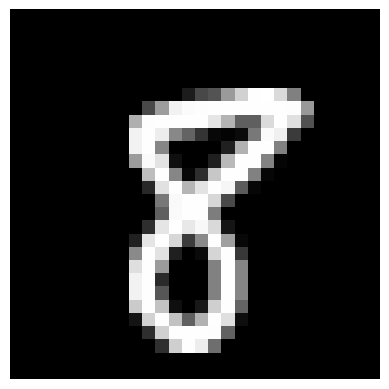

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
import random
c = random.randint(0, 59999)
print("正確答案", y_train[c])
plt.axis("off")
# 取消坐標軸
plt.imshow(x_train[c], cmap="gray")

In [4]:
import pandas as pd
pd.DataFrame(x_train[c])

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,254,255,218,128,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,254,254,254,253,152,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,175,...,95,219,254,224,81,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,242,...,120,251,240,59,0,0,0,0,0,0


In [5]:
x_train_shape = x_train.reshape(60000, 784) / 255
x_test_shape = x_test.reshape(10000, 784) / 255
# 處理圖片
x_train_shape[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [6]:
from keras.utils import to_categorical
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)
# 處理答案
print("處理前:", y_train[0])
print("處理後:", y_train_cat[0])

處理前: 5
處理後: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [7]:
from keras.models import Sequential
# 引入神經網路支架
from keras.layers import Dense
# 引入神經網路內層
model = Sequential()
model.add(Dense(128, activation="relu", input_dim=784))
# 中間神經設定activation="relu", 避免梯度下降
model.add(Dense(10, activation="softmax"))
# 一個輸出神經設定activation="sigmoid", 否則設定activation="softmax"
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
# 一個輸出神經設定loss="binary_crossentropy", 否則設定loss="categorical_crossentropy"

In [9]:
model.fit(x_train_shape, y_train_cat,
     batch_size=200, epochs=10, validation_split=0.1, verbose=2)
# epochs意思是模型訓練幾次

Epoch 1/10
270/270 - 3s - loss: 0.4292 - accuracy: 0.8820 - val_loss: 0.1932 - val_accuracy: 0.9470 - 3s/epoch - 10ms/step
Epoch 2/10
270/270 - 1s - loss: 0.2019 - accuracy: 0.9424 - val_loss: 0.1354 - val_accuracy: 0.9645 - 1s/epoch - 5ms/step
Epoch 3/10
270/270 - 1s - loss: 0.1483 - accuracy: 0.9577 - val_loss: 0.1181 - val_accuracy: 0.9660 - 1s/epoch - 6ms/step
Epoch 4/10
270/270 - 2s - loss: 0.1172 - accuracy: 0.9669 - val_loss: 0.0955 - val_accuracy: 0.9738 - 2s/epoch - 6ms/step
Epoch 5/10
270/270 - 1s - loss: 0.0956 - accuracy: 0.9726 - val_loss: 0.0893 - val_accuracy: 0.9758 - 1s/epoch - 5ms/step
Epoch 6/10
270/270 - 2s - loss: 0.0808 - accuracy: 0.9768 - val_loss: 0.0843 - val_accuracy: 0.9730 - 2s/epoch - 8ms/step
Epoch 7/10
270/270 - 2s - loss: 0.0690 - accuracy: 0.9806 - val_loss: 0.0809 - val_accuracy: 0.9758 - 2s/epoch - 7ms/step
Epoch 8/10
270/270 - 1s - loss: 0.0582 - accuracy: 0.9836 - val_loss: 0.0767 - val_accuracy: 0.9782 - 1s/epoch - 6ms/step
Epoch 9/10
270/270 - 2s

In [10]:
model.save("MNIST.h5")
# 儲存模型

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [11]:
from keras.models import load_model
loaded = load_model("MNIST.h5")
# 載入模型

In [12]:
loaded.evaluate(x_test_shape, y_test_cat)
# 使用模型

313/313 [==============================] - 1s 2ms/step - loss: 0.0780 - accuracy: 0.9763


[0.0779614970088005, 0.9763000011444092]